In [ ]:
%pip install --upgrade numpy scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 77.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.


In [ ]:
!pip install gensim

  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.4
    Uninstalling numpy-2.2.4:
      Successfully uninstalled numpy-2.2.4


Epoch 1/25
Training Loss: 0.0281, Training Accuracy: 0.1758
Validation Loss: 0.0284, Validation Accuracy: 0.1903
Epoch 2/25
Training Loss: 0.0280, Training Accuracy: 0.1957
Validation Loss: 0.0283, Validation Accuracy: 0.1956
Epoch 3/25
Training Loss: 0.0279, Training Accuracy: 0.2156
Validation Loss: 0.0282, Validation Accuracy: 0.2301
Epoch 4/25
Training Loss: 0.0278, Training Accuracy: 0.2488
Validation Loss: 0.0280, Validation Accuracy: 0.2735
Epoch 5/25
Training Loss: 0.0276, Training Accuracy: 0.2692
Validation Loss: 0.0278, Validation Accuracy: 0.2850
Epoch 6/25
Training Loss: 0.0274, Training Accuracy: 0.2984
Validation Loss: 0.0275, Validation Accuracy: 0.3319
Epoch 7/25
Training Loss: 0.0272, Training Accuracy: 0.3161
Validation Loss: 0.0273, Validation Accuracy: 0.3726
Epoch 8/25
Training Loss: 0.0269, Training Accuracy: 0.3367
Validation Loss: 0.0271, Validation Accuracy: 0.3929
Epoch 9/25
Training Loss: 0.0267, Training Accuracy: 0.3538
Validation Loss: 0.0269, Validation 

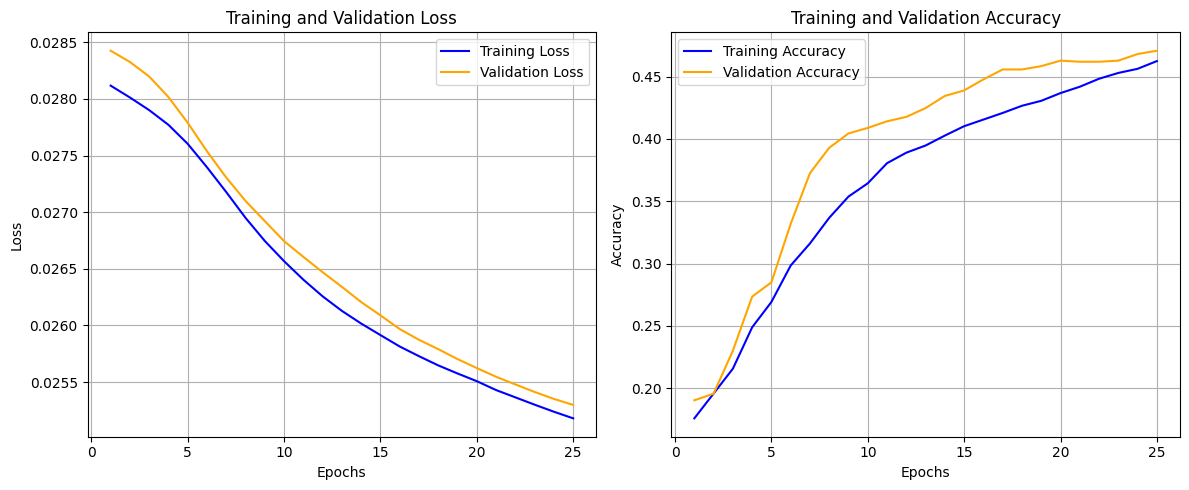

Fine-tuning Epoch 1/5
Training Loss: 0.0250, Training Accuracy: 0.4815
Validation Loss: 0.0251, Validation Accuracy: 0.4920
Fine-tuning Epoch 2/5
Training Loss: 0.0248, Training Accuracy: 0.5070
Validation Loss: 0.0249, Validation Accuracy: 0.5097
Fine-tuning Epoch 3/5
Training Loss: 0.0245, Training Accuracy: 0.5298
Validation Loss: 0.0247, Validation Accuracy: 0.5248
Fine-tuning Epoch 4/5
Training Loss: 0.0243, Training Accuracy: 0.5510
Validation Loss: 0.0245, Validation Accuracy: 0.5531
Fine-tuning Epoch 5/5
Training Loss: 0.0241, Training Accuracy: 0.5727
Validation Loss: 0.0244, Validation Accuracy: 0.5735


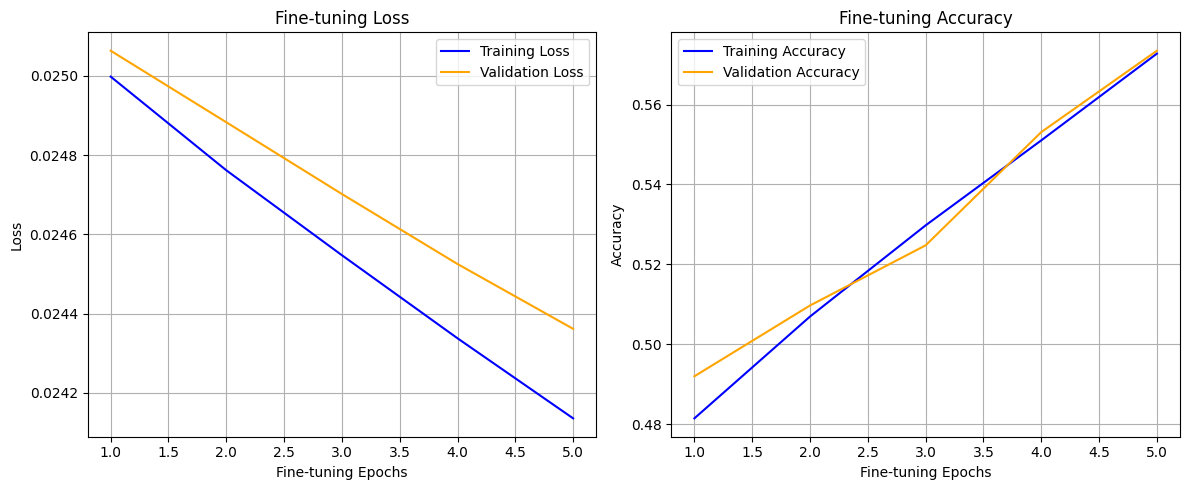

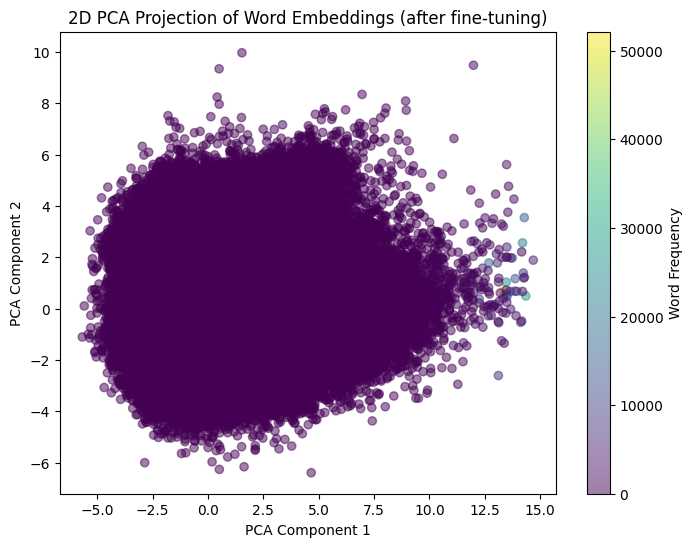

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from gensim.utils import simple_preprocess
from collections import Counter

# 1. Load the dataset (using a subset of categories)
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'sci.electronics', 'talk.politics.guns','sci.crypt']
newsgroups = fetch_20newsgroups(subset='all', categories=categories, remove=('headers', 'footers', 'quotes'))
texts = newsgroups.data
labels = newsgroups.target
num_classes = len(categories)
training_loss = []
validation_loss = []
training_acc = []
validation_acc = []
fine_tune_epochs = 5

# 2. Tokenize texts
tokenized_texts = [simple_preprocess(text) for text in texts]

# 3. Load GloVe embeddings and create vocabulary index
def load_glove(glove_path):
    glove_dict = {}
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vec = np.array(parts[1:], dtype=np.float32)
            glove_dict[word] = vec
    return glove_dict

glove_path = 'glove.6B.100d.txt'  # Adjust path as necessary
glove_dict = load_glove(glove_path)

# Build vocabulary: assign an index to each word in the GloVe file that appears in our texts
vocab = {}
embedding_list = []
for word, vec in glove_dict.items():
    vocab[word] = len(vocab)
    embedding_list.append(vec)
embedding_matrix = torch.tensor(np.array(embedding_list))  # (vocab_size, embedding_dim)

# 4. Create doc2ind function to map document tokens to indices
def doc2ind(doc, vocab, max_len=100):
    """
    Convert a tokenized document to a list of indices.
    Pads with 0 (or another special index) if the document is shorter than max_len.
    """
    indices = [vocab.get(word, 0) for word in doc]  # OOV words get index 0
    if len(indices) < max_len:
        indices.extend([0] * (max_len - len(indices)))
    else:
        indices = indices[:max_len]
    return indices

max_len = 500  # maximum number of tokens per document
doc_indices = [doc2ind(doc, vocab, max_len) for doc in tokenized_texts]
doc_tensor = torch.LongTensor(doc_indices)
labels_tensor = torch.LongTensor(labels)

# Split data
X_train, X_test, y_train, y_test = train_test_split(doc_tensor, labels_tensor, test_size=0.2, random_state=42)

# 5. Define the enhanced model using GloVe embeddings
embedding_dim = embedding_matrix.shape[1]
vocab_size = embedding_matrix.shape[0]

# Initialize embedding layer with GloVe embeddings (frozen initially)
glove_emb = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)

# Enhanced model: Embedding -> Mean Pooling -> Two Linear Layers -> Softmax
class SimpleNN(nn.Module):
    def __init__(self, embedding_layer, embedding_dim, num_classes):
        super(SimpleNN, self).__init__()
        self.embedding = embedding_layer
        self.fc1 = nn.Linear(embedding_dim, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # x shape: (batch_size, max_len)
        x_emb = self.embedding(x)  # (batch_size, max_len, embedding_dim)
        # Mean pooling over sequence length
        x_mean = x_emb.mean(dim=1)  # (batch_size, embedding_dim)
        x = self.fc1(x_mean)
        x = self.relu(x)
        logits = self.fc2(x)
        return torch.softmax(logits, dim=1)

model = SimpleNN(glove_emb, embedding_dim, num_classes)

# 6. Training loop (for demonstration, a basic loop)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
batch_size = 64
epochs = 25  # adjust based on available compute

def get_batches(X, y, batch_size):
    for i in range(0, len(X), batch_size):
        yield X[i:i+batch_size], y[i:i+batch_size]

def calculate_accuracy(model, X, y, batch_size):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in get_batches(X, y, batch_size):
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    return running_loss, correct / total

# Modified training loop
model.train()
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    correct = 0
    total = 0

    # Training phase
    for X_batch, y_batch in get_batches(X_train, y_train, batch_size):
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

    # Calculate training metrics
    avg_train_loss = epoch_loss / len(X_train)
    train_accuracy = correct / total

    # Calculate validation metrics
    val_loss, val_accuracy = calculate_accuracy(model, X_test, y_test, batch_size)
    val_loss = val_loss / len(X_test)

    # Store metrics
    training_loss.append(avg_train_loss)
    validation_loss.append(val_loss)
    training_acc.append(train_accuracy)
    validation_acc.append(val_accuracy)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
    print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

# Plot Training Dynamics - Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), training_loss, label='Training Loss', color='blue')
plt.plot(range(1, epochs + 1), validation_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# Plot Training Dynamics - Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), training_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, epochs + 1), validation_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Continue with fine-tuning section
fine_tuning_train_loss = []
fine_tuning_val_loss = []
fine_tuning_train_acc = []
fine_tuning_val_acc = []

model.embedding.weight.requires_grad = True
optimizer = optim.Adam(model.parameters(), lr=0.0005)

for epoch in range(fine_tune_epochs):
    model.train()
    epoch_loss = 0.0
    correct = 0
    total = 0

    # Training phase
    for X_batch, y_batch in get_batches(X_train, y_train, batch_size):
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

    # Calculate metrics
    avg_train_loss = epoch_loss / len(X_train)
    train_accuracy = correct / total
    val_loss, val_accuracy = calculate_accuracy(model, X_test, y_test, batch_size)
    val_loss = val_loss / len(X_test)

    # Store metrics
    fine_tuning_train_loss.append(avg_train_loss)
    fine_tuning_val_loss.append(val_loss)
    fine_tuning_train_acc.append(train_accuracy)
    fine_tuning_val_acc.append(val_accuracy)

    print(f"Fine-tuning Epoch {epoch+1}/{fine_tune_epochs}")
    print(f"Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
    print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

# Plot Fine-tuning Dynamics
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, fine_tune_epochs + 1), fine_tuning_train_loss, label='Training Loss', color='blue')
plt.plot(range(1, fine_tune_epochs + 1), fine_tuning_val_loss, label='Validation Loss', color='orange')
plt.xlabel('Fine-tuning Epochs')
plt.ylabel('Loss')
plt.title('Fine-tuning Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, fine_tune_epochs + 1), fine_tuning_train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, fine_tune_epochs + 1), fine_tuning_val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Fine-tuning Epochs')
plt.ylabel('Accuracy')
plt.title('Fine-tuning Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 9. Visualize the embeddings in 2D using PCA
# For visualization, you might want to sample a subset of words or documents.
# Here, we project the (potentially tuned) embedding weights.
final_embeddings = model.embedding.weight.detach().cpu().numpy()

# Normalize embeddings
scaler = StandardScaler()
scaled_embeddings = scaler.fit_transform(final_embeddings)

# Reduce dimensions to 2D
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(scaled_embeddings)

# Compute word frequencies for color coding
word_freq = Counter(word for doc in tokenized_texts for word in doc)
freq_values = [word_freq.get(word, 0) for word in vocab]

# Plotting training and test data stragiht line
plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=freq_values, cmap='viridis', alpha=0.5)
plt.colorbar(label='Word Frequency')
plt.title("2D PCA Projection of Word Embeddings (after fine-tuning)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()